In [1]:
# Beam Reaction, Shear Force and Bending Moment Diagram
# Simply supported beam with multiple point loads

import numpy as np
import matplotlib.pyplot as plt

# beam properties
L = 10.0    # beam length (m)

# point loads — [position (m), magnitude (N)]
# positive = downward
loads = [
    [2.0, 300.0],
    [5.0, 500.0],
    [8.0, 200.0]
]

# calculate reactions using equilibrium
# sum Fy = 0: Ay + By = sum of all loads
# sum M about A = 0: By*L = sum(P*x)

total_load = sum(P for x, P in loads)
moment_A = sum(P * x for x, P in loads)

By = moment_A / L
Ay = total_load - By

print("=== Beam Reaction Calculator ===")
print("Beam length:   " + str(L) + " m")
print("")
print("Applied loads:")
for x, P in loads:
    print("  " + str(P) + " N at x = " + str(x) + " m")
print("")
print("Reactions:")
print("  Ay (left):   " + str(round(Ay, 3)) + " N")
print("  By (right):  " + str(round(By, 3)) + " N")
print("")
print("Verification:")
print("  Sum Fy:      " + str(round(Ay + By - total_load, 6)) + " N (should be 0)")

=== Beam Reaction Calculator ===
Beam length:   10.0 m

Applied loads:
  300.0 N at x = 2.0 m
  500.0 N at x = 5.0 m
  200.0 N at x = 8.0 m

Reactions:
  Ay (left):   530.0 N
  By (right):  470.0 N

Verification:
  Sum Fy:      0.0 N (should be 0)


In [2]:
# Shear Force and Bending Moment Diagrams

# create x positions along beam
x = np.linspace(0, L, 1000)

# calculate shear force at each point
def shear_force(x_pos):
    V = Ay
    for pos, P in loads:
        if x_pos > pos:
            V = V - P
    return V

# calculate bending moment at each point
def bending_moment(x_pos):
    M = Ay * x_pos
    for pos, P in loads:
        if x_pos > pos:
            M = M - P * (x_pos - pos)
    return M

# compute diagrams
V = np.array([shear_force(xi) for xi in x])
M = np.array([bending_moment(xi) for xi in x])

# find max values
V_max = max(abs(V))
M_max = max(abs(M))
M_max_loc = x[np.argmax(abs(M))]

print("=== Shear Force and Bending Moment Summary ===")
print("Max shear force:    " + str(round(V_max, 2)) + " N")
print("Max bending moment: " + str(round(M_max, 2)) + " N.m")
print("Location of Mmax:   x = " + str(round(M_max_loc, 2)) + " m")

=== Shear Force and Bending Moment Summary ===
Max shear force:    530.0 N
Max bending moment: 1748.85 N.m
Location of Mmax:   x = 4.99 m


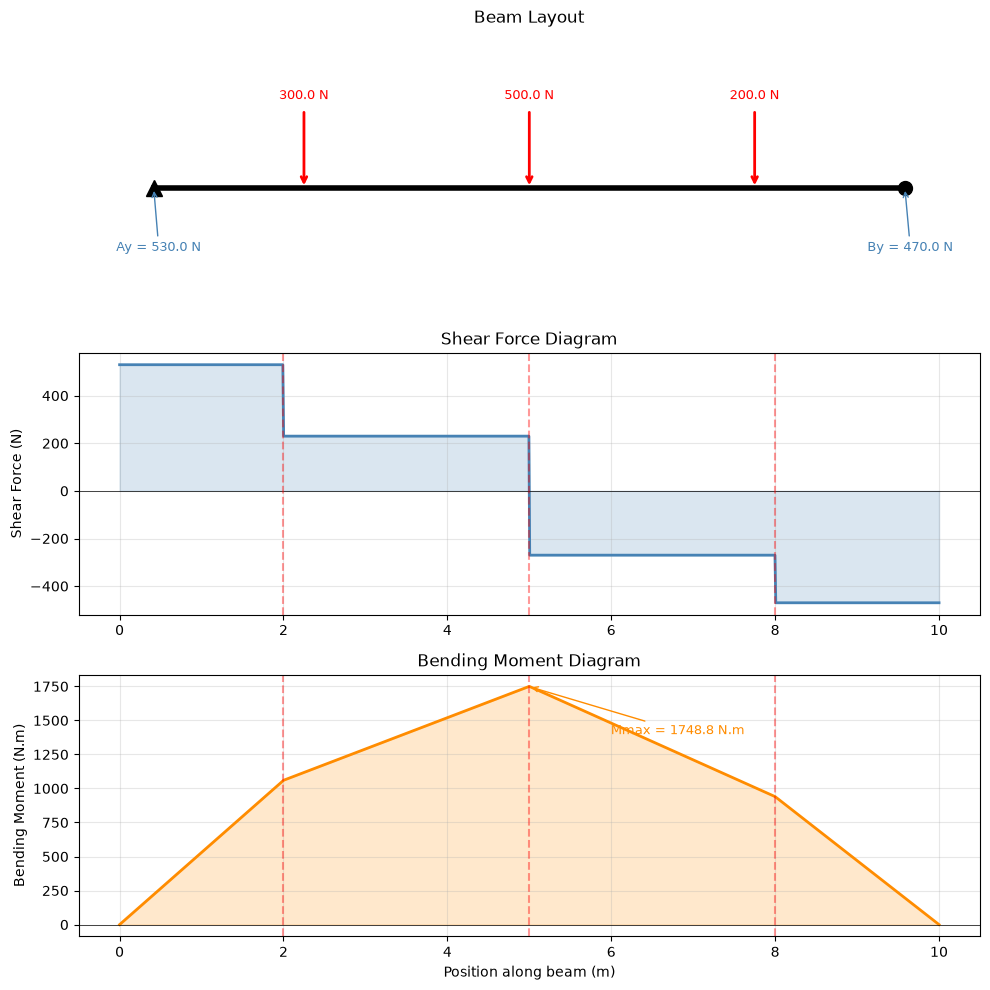

diagram saved


In [3]:
# Plot Beam, SFD and BMD

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

# --- beam diagram ---
ax1.plot([0, L], [0, 0], 'k-', linewidth=4)
ax1.plot(0, 0, 'k^', markersize=12)
ax1.plot(L, 0, 'ko', markersize=10)

for pos, P in loads:
    ax1.annotate('', xy=(pos, 0), xytext=(pos, 1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax1.text(pos, 1.7, str(P) + ' N', ha='center', color='red', fontsize=9)

ax1.annotate('Ay = ' + str(round(Ay, 1)) + ' N',
            xy=(0, 0), xytext=(-0.5, -1.2), fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))
ax1.annotate('By = ' + str(round(By, 1)) + ' N',
            xy=(L, 0), xytext=(L-0.5, -1.2), fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

ax1.set_xlim(-1, L+1)
ax1.set_ylim(-2, 3)
ax1.axis('off')
ax1.set_title('Beam Layout')

# --- shear force diagram ---
ax2.plot(x, V, color='steelblue', linewidth=2)
ax2.fill_between(x, V, 0, alpha=0.2, color='steelblue')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Shear Force (N)')
ax2.set_title('Shear Force Diagram')
ax2.grid(True, alpha=0.3)

for pos, P in loads:
    ax2.axvline(x=pos, color='red', linestyle='--', alpha=0.4)

# --- bending moment diagram ---
ax3.plot(x, M, color='darkorange', linewidth=2)
ax3.fill_between(x, M, 0, alpha=0.2, color='darkorange')
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_xlabel('Position along beam (m)')
ax3.set_ylabel('Bending Moment (N.m)')
ax3.set_title('Bending Moment Diagram')
ax3.grid(True, alpha=0.3)

ax3.annotate('Mmax = ' + str(round(M_max, 1)) + ' N.m',
            xy=(M_max_loc, M_max),
            xytext=(M_max_loc + 1, M_max * 0.8),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'))

for pos, P in loads:
    ax3.axvline(x=pos, color='red', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('beam_sfd_bmd.png')
plt.show()
print("diagram saved")